# Clase 5 — Aproximación de funciones, DQN y *Policy Gradients* (versión R)

**Curso:** Aprendizaje por Refuerzo: Fundamentos y Aplicaciones
**Institución:** Universidad Austral — Facultad de Ingeniería (Posgrados)
**Docente:** Dr. Darío Ezequiel Díaz
**Fecha:** 2 de junio de 2026

---

## Resumen del cuaderno

Esta es la contraparte en **R** del cuaderno Python `Clase05_DQN_PolicyGradients.ipynb`. Como en toda la Unidad 4, el aprendizaje por refuerzo profundo se apoya en **PyTorch**, cuyo ecosistema vive en Python; el cuaderno R accede a él mediante **`reticulate`** y el entorno conda `rl-docencia`, exactamente como anuncia la diapositiva de práctica. La filosofía es nítida: **el cómputo numérico ocurre en el núcleo de Python** —idéntico en lógica al del cuaderno Python—, mientras que **R orquesta los experimentos, organiza los resultados en `data.frame` y produce todas las visualizaciones con `ggplot2`**. Es el flujo de trabajo natural del estadístico que habita R pero desea el poder del RL profundo.

> **Pregunta vertebradora.** ¿Cómo aprovecha un usuario de R el ecosistema de aprendizaje por refuerzo profundo de Python sin abandonar su lenguaje, y qué cuidados exige el puente entre ambos mundos?

La estructura espeja los bloques del cuaderno Python: configuración y puente `reticulate`; el entorno CartPole; DQN; REINFORCE con y sin línea base; PPO; la comparación; y los ejercicios.

> **Compatibilidad.** En la máquina del docente, el cuaderno emplea `use_condaenv("rl-docencia")`. El patrón de activación incluye un repliegue al Python activo y una **instalación protegida** que, si faltan, añade `gymnasium`, `torch` o `stable-baselines3` en el mismo intérprete que usa `reticulate`; de este modo el cuaderno corre también en **Google Colab** (kernel R) o en un entorno local sin configuración previa. Las dispersiones se reportan con `sd()`, que en R es ya el estimador **insesgado** (denominador $n-1$), la convención del curso.

## Bloque 0 — Configuración del entorno y puente con Python

Cargamos los paquetes de R, fijamos las **dos semillas** de la convención del curso y la paleta institucional, y tendemos el puente con Python mediante `reticulate`.

In [1]:
# --- Paso 1: paquetes R (con soporte para Google Colab) ---
ruta_setup_personal <- "/content/drive/MyDrive/R_Colab/setup_R_colab.R"
if (file.exists(ruta_setup_personal)) {
  source(ruta_setup_personal)
} else {
  paquetes <- c("ggplot2", "dplyr", "tidyr")
  faltantes <- paquetes[!sapply(paquetes, function(p) requireNamespace(p, quietly = TRUE))]
  if (length(faltantes) > 0) install.packages(faltantes, quiet = TRUE)
}
suppressMessages({ library(ggplot2); library(dplyr); library(tidyr) })

# Dos semillas (convención del curso)
SEMILLA_GLOBAL <- 42L   # experimentos estadísticos (promedios sobre réplicas)
SEMILLA_VIS    <- 21L   # visualización de un único episodio (Bloque 1)
set.seed(SEMILLA_GLOBAL)

# Paleta institucional Austral
COLOR_NAVY <- "#1E3A5F"; COLOR_ORANGE <- "#D86A2C"; COLOR_TEAL <- "#2E8A99"
COLOR_GRAY <- "#4A4A4A"; COLOR_YELLOW <- "#B8860B"; COLOR_RED <- "#C0392B"

# Tema gráfico institucional
tema_austral <- theme_minimal(base_size = 12) +
  theme(plot.title = element_text(color = COLOR_NAVY, face = "bold"),
        axis.title = element_text(color = COLOR_NAVY),
        axis.text  = element_text(color = COLOR_GRAY),
        panel.grid.minor = element_blank(), legend.position = "bottom")
theme_set(tema_austral)

cat("Entorno R configurado.\n"); cat(R.version.string, "\n")

Entorno R configurado.


R version 4.3.3 (2024-02-29) 


In [2]:
# --- Paso 2: puente con Python vía reticulate ---
Sys.setenv(PYTHONNOUSERSITE = "1")
suppressMessages(library(reticulate))

# 1) Entorno conda del curso; si no existe (p. ej. en Google Colab), Python activo.
ok_py <- tryCatch({ use_condaenv("rl-docencia", required = TRUE); TRUE },
  error = function(e) {
    message("Entorno conda 'rl-docencia' no disponible; uso el Python activo."); FALSE })

# 2) Instalación protegida de dependencias en el MISMO Python que usa reticulate.
#    En Google Colab, torch suele venir preinstalado; gymnasium y SB3 no.
deps <- c(gymnasium = "gymnasium", torch = "torch", stable_baselines3 = "stable-baselines3")
faltan <- deps[!vapply(names(deps), py_module_available, logical(1))]
if (length(faltan) > 0) {
  message("Instalando dependencias de Python: ", paste(faltan, collapse = ", "), " ...")
  py_run_string(sprintf(
    "import sys, subprocess; subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', %s])",
    paste(sprintf("'%s'", unname(faltan)), collapse = ", ")))
}

# 3) Importaciones con convert = FALSE: los objetos pesados (entornos, tensores)
#    permanecen como referencias de Python; sólo convertimos valores escalares.
gym   <- import("gymnasium", convert = FALSE)
torch <- import("torch", convert = FALSE)
sb3   <- tryCatch(import("stable_baselines3", convert = FALSE), error = function(e) NULL)

cat("gymnasium", as.character(py_to_r(gym$`__version__`)),
    "| torch", as.character(py_to_r(torch$`__version__`)), "\n")
if (!is.null(sb3)) cat("stable-baselines3", as.character(py_to_r(sb3$`__version__`)), "\n")

Entorno conda 'rl-docencia' no disponible; uso el Python activo.



gymnasium 1.2.3 | torch 2.12.0+cu130 


stable-baselines3 2.8.0 


### Sobre el puente y las conversiones defensivas

`reticulate` traduce automáticamente entre objetos de Python y de R, pero esa traducción es *recursiva*: convertir un objeto complejo —un entorno de Gymnasium, un tensor de PyTorch— arrastra toda su estructura interna y puede desbordar la pila de R. Por eso importamos los módulos con **`convert = FALSE`**: los objetos pesados quedan como **referencias** de Python, y convertimos a R **sólo los valores que necesitamos** mediante `py_to_r()`, `as.numeric()`, `as.logical()` o `as.integer()`. Este patrón defensivo, institucionalizado en los cuadernos R del curso, evita errores silenciosos de *broadcasting* y desbordes de pila.

En coherencia con esta filosofía, alojamos el **núcleo algorítmico** —las redes y los bucles de entrenamiento de DQN, REINFORCE y PPO— en Python, invocado vía `reticulate`. Es la misma lógica del cuaderno Python; R recibe de vuelta **listas planas de números** que convierte sin fricción a vectores y `data.frame`, y sobre los que ejerce su verdadero oficio: la organización y la visualización con `ggplot2`.

In [3]:
nucleo_py <- r"----(
# =====================================================================
#  nucleo_rl.py — Núcleo algorítmico compartido de la Clase 5
#  Invocado desde el cuaderno R a través de reticulate. Idéntico en
#  lógica al cuaderno de Python; devuelve listas planas para que
#  reticulate las convierta limpiamente a vectores de R.
# =====================================================================
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from collections import deque
import random
import gymnasium as gym

_ENV_ID = "CartPole-v1"
_e = gym.make(_ENV_ID)
DIM_OBS = int(_e.observation_space.shape[0])
N_ACCIONES = int(_e.action_space.n)
_e.close()

def _fijar_semilla(s):
    s = int(s); np.random.seed(s); random.seed(s); torch.manual_seed(s)

# ---------------- estructuras ----------------
class RedQ(nn.Module):
    def __init__(self, d, n, h=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d, h), nn.ReLU(),
                                 nn.Linear(h, h), nn.ReLU(), nn.Linear(h, n))
    def forward(self, x): return self.net(x)

class Memoria:
    def __init__(self, cap): self.b = deque(maxlen=int(cap))
    def add(self, *t): self.b.append(t)
    def sample(self, n, rng):
        idx = rng.integers(0, len(self.b), size=int(n))
        s,a,r,s2,d = zip(*(self.b[i] for i in idx))
        return (torch.tensor(np.array(s),dtype=torch.float32),
                torch.tensor(a,dtype=torch.int64).unsqueeze(1),
                torch.tensor(r,dtype=torch.float32).unsqueeze(1),
                torch.tensor(np.array(s2),dtype=torch.float32),
                torch.tensor(d,dtype=torch.float32).unsqueeze(1))
    def __len__(self): return len(self.b)

class RedPolitica(nn.Module):
    def __init__(self, d, n, h=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,h), nn.ReLU(), nn.Linear(h,n))
    def forward(self, x): return self.net(x)

class RedValor(nn.Module):
    def __init__(self, d, h=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,h), nn.ReLU(), nn.Linear(h,1))
    def forward(self, x): return self.net(x)

# ---------------- rollout de visualización ----------------
def rollout_visualizacion(semilla):
    '''Un episodio bajo política aleatoria; devuelve la traza de las 4 coordenadas.'''
    env = gym.make(_ENV_ID); rng = np.random.default_rng(int(semilla))
    s,_ = env.reset(seed=int(semilla)); traza=[list(map(float,s))]; done=False
    while not done:
        s,r,term,trunc,_ = env.step(int(rng.integers(N_ACCIONES)))
        traza.append(list(map(float,s))); done = term or trunc
    env.close()
    return traza  # lista de listas (n_pasos x 4)

def retorno_aleatorio(semilla, n_ep=50):
    env = gym.make(_ENV_ID); rng = np.random.default_rng(int(semilla)); rets=[]
    for _ in range(int(n_ep)):
        s,_ = env.reset(seed=int(rng.integers(1e6))); G=0.0; done=False
        while not done:
            s,r,term,trunc,_ = env.step(int(rng.integers(N_ACCIONES)))
            G+=r; done=term or trunc
        rets.append(float(G))
    env.close()
    return rets

# ---------------- DQN ----------------
def entrenar_dqn(semilla, n_pasos, C=500, gamma=0.99, lr=1e-3, batch=64,
                 cap=10000, inicio=1000, eps0=1.0, eps_min=0.02, eps_decay=0.995,
                 doble=False):
    _fijar_semilla(semilla); rng = np.random.default_rng(int(semilla))
    env = gym.make(_ENV_ID)
    q, qo = RedQ(DIM_OBS,N_ACCIONES), RedQ(DIM_OBS,N_ACCIONES)
    qo.load_state_dict(q.state_dict())
    opt = torch.optim.Adam(q.parameters(), lr=lr); mem = Memoria(cap)
    eps=eps0; rets=[]; pasos=[]; s,_=env.reset(seed=int(semilla)); G=0.0; t=0
    while t < int(n_pasos):
        if rng.random() < eps: a = int(rng.integers(N_ACCIONES))
        else:
            with torch.no_grad(): a = int(q(torch.tensor(s,dtype=torch.float32)).argmax())
        s2,r,term,trunc,_ = env.step(a); mem.add(s,a,r,s2,float(term))
        s=s2; G+=r; t+=1
        if len(mem)>=inicio:
            bs,ba,br,bs2,bd = mem.sample(batch,rng)
            with torch.no_grad():
                if doble:
                    asel = q(bs2).argmax(1,keepdim=True); qn = qo(bs2).gather(1,asel)
                else:
                    qn = qo(bs2).max(1,keepdim=True)[0]
                y = br + gamma*qn*(1-bd)
            loss = F.smooth_l1_loss(q(bs).gather(1,ba), y)
            opt.zero_grad(); loss.backward(); opt.step()
            if t % int(C) == 0: qo.load_state_dict(q.state_dict())
        if term or trunc:
            rets.append(float(G)); pasos.append(int(t))
            eps = max(eps_min, eps*eps_decay); s,_=env.reset(); G=0.0
    env.close()
    return {"retornos": rets, "pasos": pasos}

# ---------------- REINFORCE ----------------
def entrenar_reinforce(semilla, n_episodios, usar_baseline=False, gamma=0.99, lr=1e-2):
    _fijar_semilla(semilla); env = gym.make(_ENV_ID)
    pol = RedPolitica(DIM_OBS,N_ACCIONES); optp = torch.optim.Adam(pol.parameters(),lr=lr)
    if usar_baseline:
        val = RedValor(DIM_OBS); optv = torch.optim.Adam(val.parameters(),lr=lr)
    rets=[]; grads=[]; pasos=[]; total=0
    for ep in range(int(n_episodios)):
        s,_ = env.reset(seed=int(semilla)+ep); lps=[]; rs=[]; vs=[]; done=False
        while not done:
            logits = pol(torch.tensor(s,dtype=torch.float32))
            dist = torch.distributions.Categorical(logits=logits)
            a = dist.sample(); lps.append(dist.log_prob(a))
            if usar_baseline: vs.append(val(torch.tensor(s,dtype=torch.float32)))
            s,r,term,trunc,_ = env.step(int(a)); rs.append(r); done=term or trunc
        G=0.0; Gs=[]
        for r in reversed(rs): G=r+gamma*G; Gs.insert(0,G)
        Gs = torch.tensor(Gs,dtype=torch.float32); lps = torch.stack(lps)
        total += len(rs); rets.append(float(sum(rs))); pasos.append(int(total))
        if usar_baseline:
            v = torch.stack(vs).squeeze(-1); vent = Gs - v.detach()
            lp = -(lps*vent).sum(); lv = F.mse_loss(v, Gs)
            optp.zero_grad(); lp.backward()
            gn = torch.sqrt(sum((p.grad**2).sum() for p in pol.parameters()))
            grads.append(float(gn)); optp.step()
            optv.zero_grad(); lv.backward(); optv.step()
        else:
            lp = -(lps*Gs).sum(); optp.zero_grad(); lp.backward()
            gn = torch.sqrt(sum((p.grad**2).sum() for p in pol.parameters()))
            grads.append(float(gn)); optp.step()
    env.close()
    return {"retornos": rets, "grad": grads, "pasos": pasos}

# ---------------- PPO (Stable-Baselines3) ----------------
def entrenar_ppo(semilla, n_pasos):
    from stable_baselines3 import PPO
    from stable_baselines3.common.monitor import Monitor
    from stable_baselines3.common.callbacks import BaseCallback
    class Reg(BaseCallback):
        def __init__(self): super().__init__(); self.r=[]; self.p=[]
        def _on_step(self):
            for info in self.locals["infos"]:
                if "episode" in info:
                    self.r.append(float(info["episode"]["r"])); self.p.append(int(self.num_timesteps))
            return True
    env = Monitor(gym.make(_ENV_ID)); cb = Reg()
    m = PPO("MlpPolicy", env, seed=int(semilla), verbose=0, n_steps=1024,
            batch_size=64, gae_lambda=0.95, clip_range=0.2, gamma=0.99)
    m.learn(total_timesteps=int(n_pasos), callback=cb); env.close()
    return {"retornos": cb.r, "pasos": cb.p}

)----"
writeLines(nucleo_py, "nucleo_core_R.py")
source_python("nucleo_core_R.py", convert = TRUE)
cat("Núcleo algorítmico cargado.  DIM_OBS =", DIM_OBS,
    " N_ACCIONES =", N_ACCIONES, "\n")

Núcleo algorítmico cargado.  DIM_OBS = 4  N_ACCIONES = 2 


In [4]:
# --- Presupuestos de cómputo (contraparte demostrativa: moderados) ---
N_REPLICAS <- 2L
DQN_PASOS  <- 12000L
REINF_EPIS <- 150L
PPO_PASOS  <- 12000L
cat(sprintf("Réplicas: %d | DQN: %d pasos | REINFORCE: %d ep | PPO: %d pasos\n",
            N_REPLICAS, DQN_PASOS, REINF_EPIS, PPO_PASOS))

Réplicas: 2 | DQN: 12000 pasos | REINFORCE: 150 ep | PPO: 12000 pasos


## Bloque 1 — El entorno CartPole-v1

Leemos las dimensiones del entorno —cuatro estados continuos, dos acciones discretas— y medimos la línea de base de una política aleatoria. Luego visualizamos, con `ggplot2`, la trayectoria de las cuatro coordenadas de un único episodio, empleando `SEMILLA_VIS`.

In [5]:
# Dimensiones y línea de base aleatoria (cómputo en el núcleo Python)
cat(sprintf("Dimensión del estado: %d (continuo) | Acciones: %d (discreto)\n",
            DIM_OBS, N_ACCIONES))

ret_azar <- as.numeric(retorno_aleatorio(SEMILLA_GLOBAL, 50L))
cat(sprintf("Política aleatoria: retorno medio = %.1f ± %.1f (sd insesgada, 50 episodios)\n",
            mean(ret_azar), sd(ret_azar)))

Dimensión del estado: 4 (continuo) | Acciones: 2 (discreto)


Política aleatoria: retorno medio = 24.9 ± 13.1 (sd insesgada, 50 episodios)


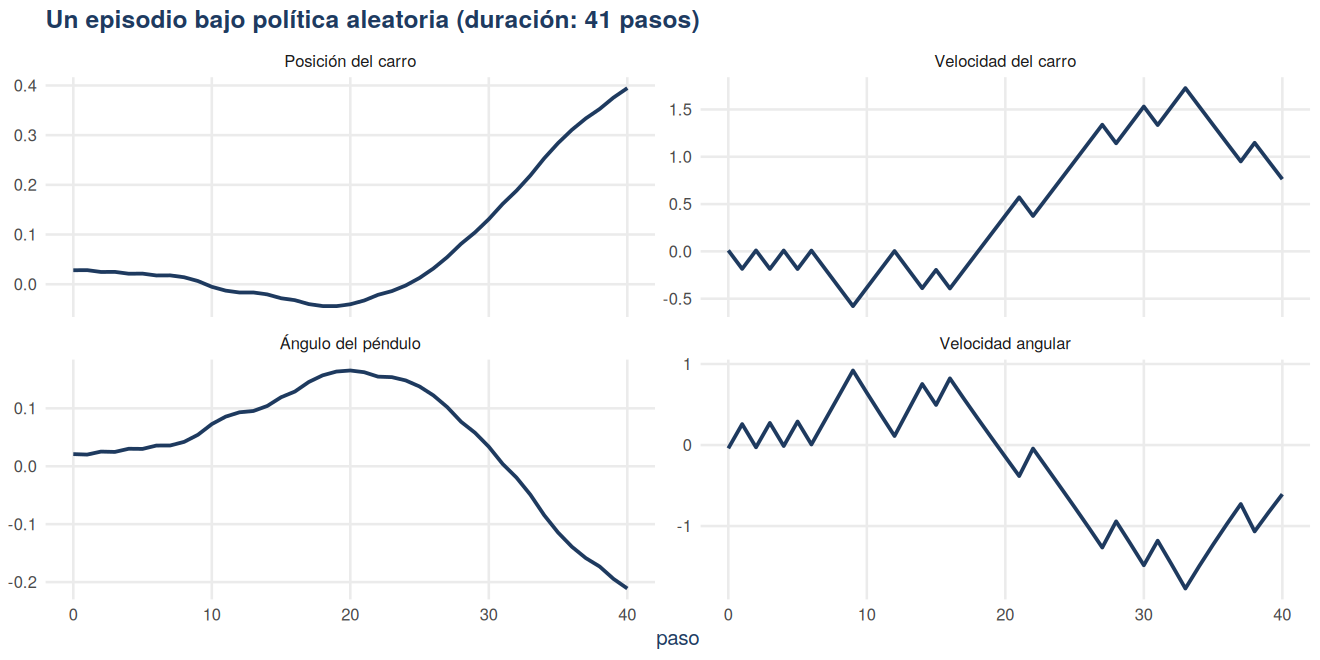

In [6]:
# Visualización ggplot2 de un episodio aleatorio (SEMILLA_VIS)
options(repr.plot.width = 11, repr.plot.height = 5.5)
traza <- rollout_visualizacion(SEMILLA_VIS)
M <- do.call(rbind, lapply(traza, as.numeric))   # conversión defensiva: lista -> matriz R
df_traza <- data.frame(
  paso = rep(seq_len(nrow(M)) - 1L, times = 4),
  valor = as.numeric(M),
  coord = factor(rep(c("Posición del carro", "Velocidad del carro",
                       "Ángulo del péndulo", "Velocidad angular"), each = nrow(M)),
                 levels = c("Posición del carro", "Velocidad del carro",
                            "Ángulo del péndulo", "Velocidad angular")))

ggplot(df_traza, aes(paso, valor)) +
  geom_line(color = COLOR_NAVY, linewidth = 0.8) +
  facet_wrap(~ coord, scales = "free_y") +
  labs(title = sprintf("Un episodio bajo política aleatoria (duración: %d pasos)", nrow(M)),
       x = "paso", y = NULL)

In [7]:
# Utilidad: media móvil causal para suavizar curvas ruidosas
media_movil <- function(x, k = 10L) {
  if (length(x) < k) return(x)
  as.numeric(stats::filter(x, rep(1/k, k), sides = 1))[k:length(x)]
}

## Bloque 2 — DQN desde cero

Invocamos el entrenamiento de DQN —repetición de experiencia y red objetivo— para `N_REPLICAS` réplicas, y construimos con `ggplot2` la curva de aprendizaje promediada con su banda de dispersión insesgada. El cómputo ocurre en el núcleo de Python; R organiza y dibuja.

In [8]:
# Entrenamiento de N_REPLICAS réplicas de DQN (cómputo en Python vía reticulate)
t0 <- Sys.time()
curvas_dqn <- vector("list", N_REPLICAS)
for (k in seq_len(N_REPLICAS)) {
  res <- entrenar_dqn(SEMILLA_GLOBAL + (k - 1L), DQN_PASOS)
  curvas_dqn[[k]] <- list(ret = as.numeric(res$retornos), pasos = as.numeric(res$pasos))
  cat(sprintf("  réplica %d: retorno final ~%.0f [%d episodios]\n",
              k, mean(tail(curvas_dqn[[k]]$ret, 10)), length(curvas_dqn[[k]]$ret)))
}
cat(sprintf("DQN entrenado en %.1f s\n", as.numeric(Sys.time() - t0, units = "secs")))

  réplica 1: retorno final ~58 [287 episodios]
  réplica 2: retorno final ~78 [253 episodios]


DQN entrenado en 153.9 s


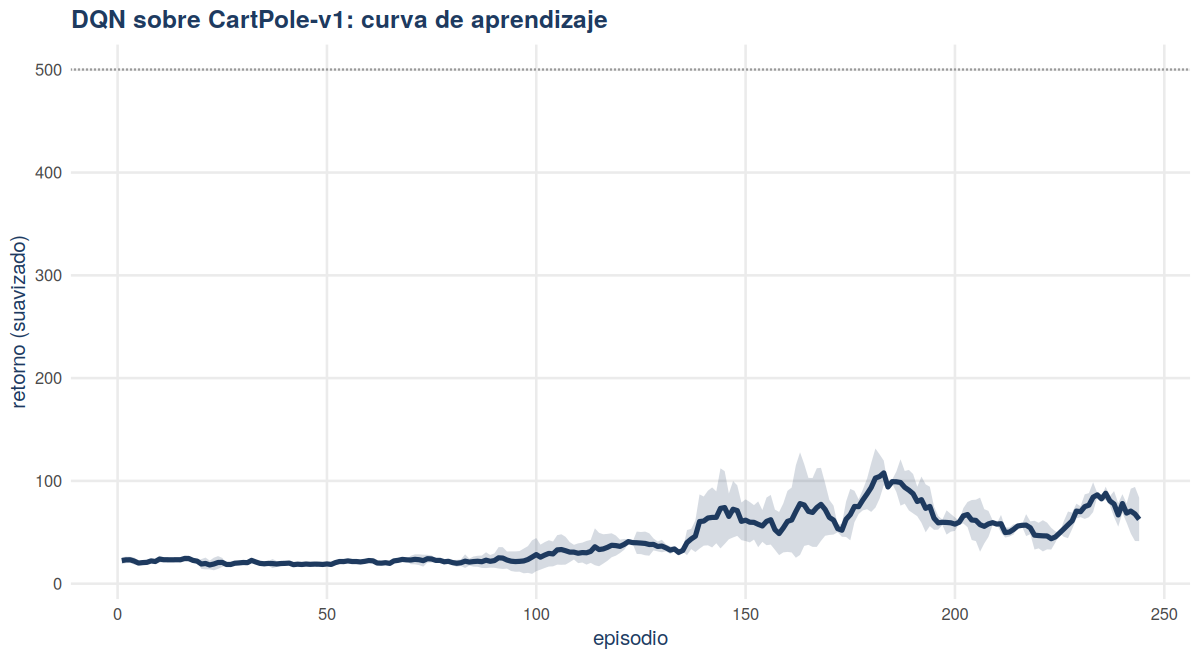

In [9]:
# Curva de aprendizaje de DQN con banda entre réplicas (ggplot2)
options(repr.plot.width = 10, repr.plot.height = 5.5)
suaves <- lapply(curvas_dqn, function(c) media_movil(c$ret, 10L))
L <- min(sapply(suaves, length))
M <- sapply(suaves, function(s) s[seq_len(L)])          # L x N_REPLICAS
df_dqn <- data.frame(
  episodio = seq_len(L),
  media = rowMeans(M),
  sd = if (ncol(M) > 1) apply(M, 1, sd) else 0)         # sd insesgada (n-1)

ggplot(df_dqn, aes(episodio, media)) +
  geom_ribbon(aes(ymin = media - sd, ymax = media + sd), fill = COLOR_NAVY, alpha = 0.18) +
  geom_line(color = COLOR_NAVY, linewidth = 1.1) +
  geom_hline(yintercept = 500, linetype = "dotted", color = COLOR_GRAY) +
  labs(title = "DQN sobre CartPole-v1: curva de aprendizaje",
       x = "episodio", y = "retorno (suavizado)")

### 2.1. El efecto del periodo de sincronización $C$

Contrastamos dos valores del periodo de la red objetivo (*ejercicio computacional 1*): un $C$ pequeño actualiza el blanco con frecuencia —fresco pero móvil—; uno grande lo estabiliza a costa de actualidad.

  C=100: retorno final ~81
  C=1000: retorno final ~114


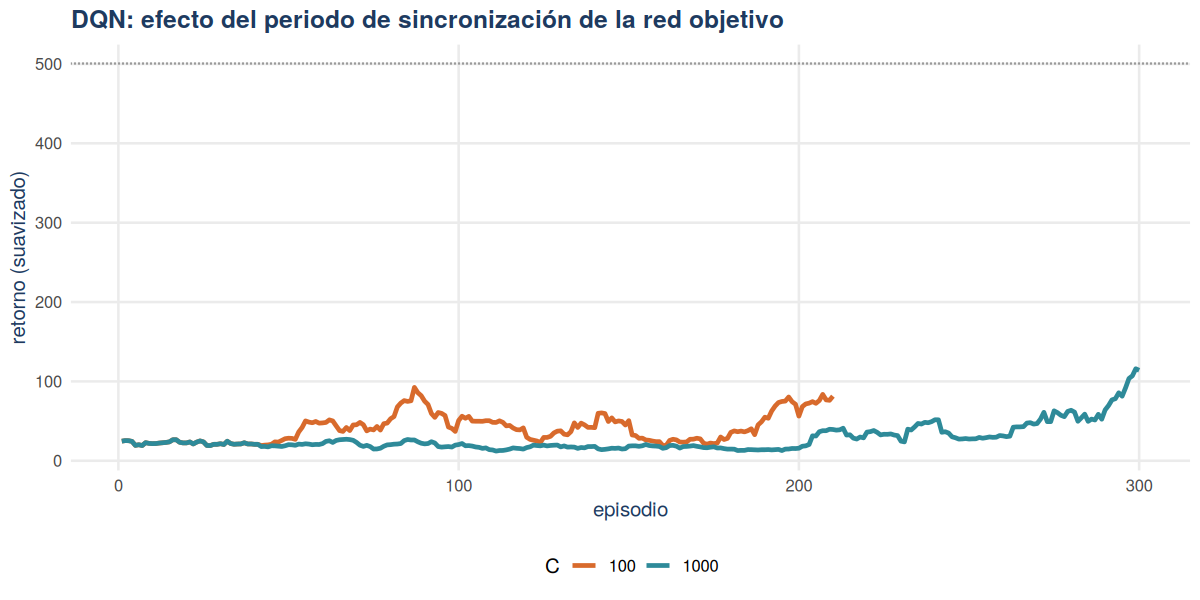

In [10]:
# Comparación del periodo C (una réplica por valor, presupuesto reducido)
options(repr.plot.width = 10, repr.plot.height = 5)
df_C <- data.frame()
for (C in c(100L, 1000L)) {
  r <- entrenar_dqn(SEMILLA_GLOBAL, 9000L, C = C)
  s <- media_movil(as.numeric(r$retornos), 10L)
  df_C <- rbind(df_C, data.frame(episodio = seq_along(s), retorno = s, C = factor(C)))
  cat(sprintf("  C=%d: retorno final ~%.0f\n", C, mean(tail(as.numeric(r$retornos), 10))))
}
ggplot(df_C, aes(episodio, retorno, color = C)) +
  geom_line(linewidth = 1) +
  scale_color_manual(values = c("100" = COLOR_ORANGE, "1000" = COLOR_TEAL)) +
  geom_hline(yintercept = 500, linetype = "dotted", color = COLOR_GRAY) +
  labs(title = "DQN: efecto del periodo de sincronización de la red objetivo",
       x = "episodio", y = "retorno (suavizado)")

## Bloque 3 — REINFORCE con y sin línea base

Entrenamos ambas variantes y comparamos su aprendizaje y la varianza de la norma del gradiente. La línea base —el valor del estado estimado por un crítico— reduce la varianza sin introducir sesgo, transformando el retorno en **ventaja**.

In [11]:
# Entrenamiento de REINFORCE sin y con línea base (N_REPLICAS cada una)
t0 <- Sys.time()
curvas_sin <- vector("list", N_REPLICAS); curvas_con <- vector("list", N_REPLICAS)
grad_sin <- list(); grad_con <- list()
for (k in seq_len(N_REPLICAS)) {
  s <- SEMILLA_GLOBAL + (k - 1L)
  r0 <- entrenar_reinforce(s, REINF_EPIS, usar_baseline = FALSE)
  r1 <- entrenar_reinforce(s, REINF_EPIS, usar_baseline = TRUE)
  curvas_sin[[k]] <- as.numeric(r0$retornos); curvas_con[[k]] <- as.numeric(r1$retornos)
  grad_sin[[k]] <- as.numeric(r0$grad);       grad_con[[k]] <- as.numeric(r1$grad)
  cat(sprintf("  réplica %d: sin base ~%.0f | con base ~%.0f\n",
              k, mean(tail(curvas_sin[[k]], 10)), mean(tail(curvas_con[[k]], 10))))
}
cat(sprintf("REINFORCE entrenado en %.1f s\n", as.numeric(Sys.time() - t0, units = "secs")))

  réplica 1: sin base ~126 | con base ~500
  réplica 2: sin base ~67 | con base ~351


REINFORCE entrenado en 74.3 s


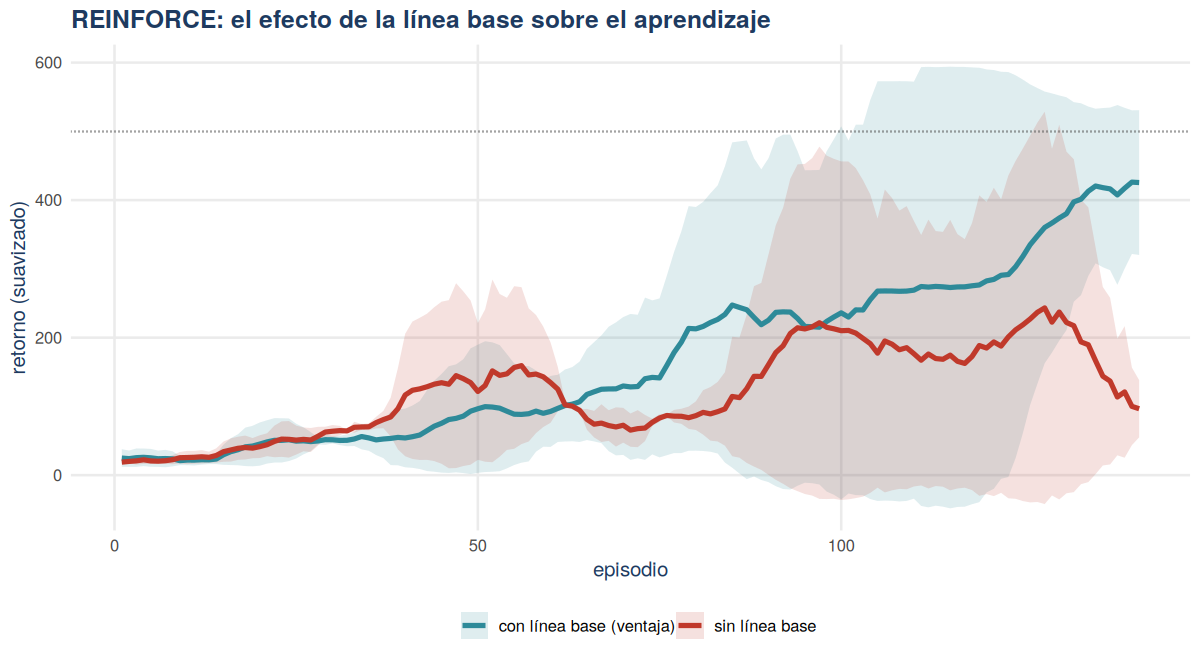

In [12]:
# Curvas comparadas: con vs sin línea base (ggplot2)
options(repr.plot.width = 10, repr.plot.height = 5.5)
banda_df <- function(curvas, etiqueta) {
  suaves <- lapply(curvas, function(c) media_movil(c, 10L))
  L <- min(sapply(suaves, length)); M <- sapply(suaves, function(s) s[seq_len(L)])
  data.frame(episodio = seq_len(L), media = rowMeans(M),
             sd = if (ncol(M) > 1) apply(M, 1, sd) else 0, variante = etiqueta)
}
df_rei <- rbind(banda_df(curvas_sin, "sin línea base"),
                banda_df(curvas_con, "con línea base (ventaja)"))
ggplot(df_rei, aes(episodio, media, color = variante, fill = variante)) +
  geom_ribbon(aes(ymin = media - sd, ymax = media + sd), alpha = 0.15, color = NA) +
  geom_line(linewidth = 1.1) +
  scale_color_manual(values = c("sin línea base" = COLOR_RED,
                                "con línea base (ventaja)" = COLOR_TEAL)) +
  scale_fill_manual(values = c("sin línea base" = COLOR_RED,
                               "con línea base (ventaja)" = COLOR_TEAL)) +
  geom_hline(yintercept = 500, linetype = "dotted", color = COLOR_GRAY) +
  labs(title = "REINFORCE: el efecto de la línea base sobre el aprendizaje",
       x = "episodio", y = "retorno (suavizado)", color = NULL, fill = NULL)

Varianza de la norma del gradiente (media, ddof=1):
  sin base: 728596.9
  con base: 56456.5
  reducción: 92 %


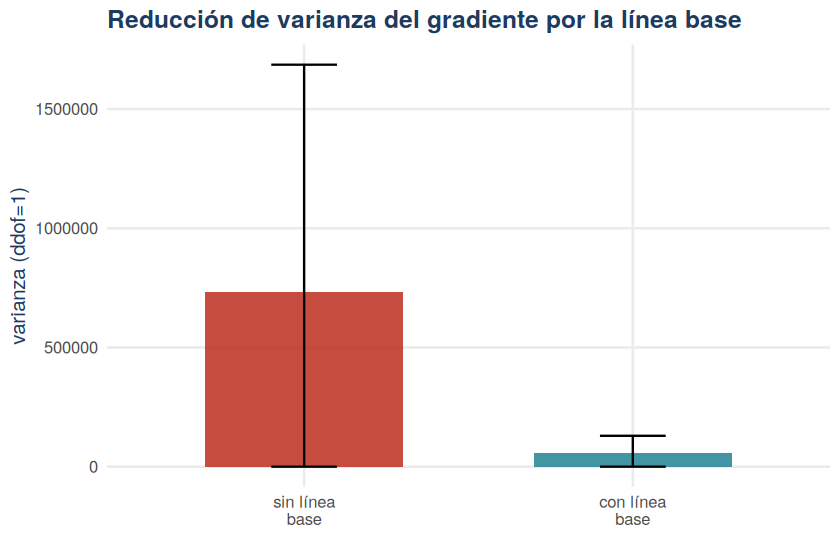

In [13]:
# Cuantificación de la varianza de la norma del gradiente (sd insesgada)
var_grad <- function(lista, frac = 0.5) {
  sapply(lista, function(g) { m <- floor(length(g) * frac); var(g[seq_len(m)]) })
}
v_sin <- var_grad(grad_sin); v_con <- var_grad(grad_con)
cat(sprintf("Varianza de la norma del gradiente (media, ddof=1):\n  sin base: %.1f\n  con base: %.1f\n  reducción: %.0f %%\n",
            mean(v_sin), mean(v_con), 100 * (1 - mean(v_con) / mean(v_sin))))

options(repr.plot.width = 7, repr.plot.height = 4.5)
df_var <- data.frame(variante = factor(c("sin línea\nbase", "con línea\nbase"),
                                        levels = c("sin línea\nbase", "con línea\nbase")),
                     varianza = c(mean(v_sin), mean(v_con)),
                     ee = c(if (length(v_sin) > 1) sd(v_sin) else 0,
                            if (length(v_con) > 1) sd(v_con) else 0))
ggplot(df_var, aes(variante, varianza, fill = variante)) +
  geom_col(width = 0.6, alpha = 0.9) +
  geom_errorbar(aes(ymin = pmax(0, varianza - ee), ymax = varianza + ee), width = 0.2) +
  scale_fill_manual(values = c(COLOR_RED, COLOR_TEAL), guide = "none") +
  labs(title = "Reducción de varianza del gradiente por la línea base",
       x = NULL, y = "varianza (ddof=1)")

## Bloque 4 — PPO con Stable-Baselines3

Invocamos PPO —actor-crítico con objetivo recortado— desde Stable-Baselines3, vía `reticulate`. Es el contraste entre el algoritmo artesanal y la herramienta industrial, todo orquestado desde R.

In [14]:
# Entrenamiento de N_REPLICAS réplicas de PPO
t0 <- Sys.time()
curvas_ppo <- vector("list", N_REPLICAS)
for (k in seq_len(N_REPLICAS)) {
  res <- entrenar_ppo(SEMILLA_GLOBAL + (k - 1L), PPO_PASOS)
  curvas_ppo[[k]] <- list(ret = as.numeric(res$retornos), pasos = as.numeric(res$pasos))
  cat(sprintf("  réplica %d: retorno final ~%.0f [%d episodios]\n",
              k, mean(tail(curvas_ppo[[k]]$ret, 10)), length(curvas_ppo[[k]]$ret)))
}
cat(sprintf("PPO entrenado en %.1f s\n", as.numeric(Sys.time() - t0, units = "secs")))

  réplica 1: retorno final ~171 [188 episodios]
  réplica 2: retorno final ~267 [188 episodios]


PPO entrenado en 40.1 s


## Bloque 5 — Comparación: eficiencia muestral y estabilidad

Confrontamos los tres algoritmos sobre un **eje común de pasos de entorno**. Para cada réplica interpolamos el retorno suavizado sobre una rejilla compartida con `approx()`, promediamos y trazamos bandas. Cerramos con una tabla de estadísticas finales.

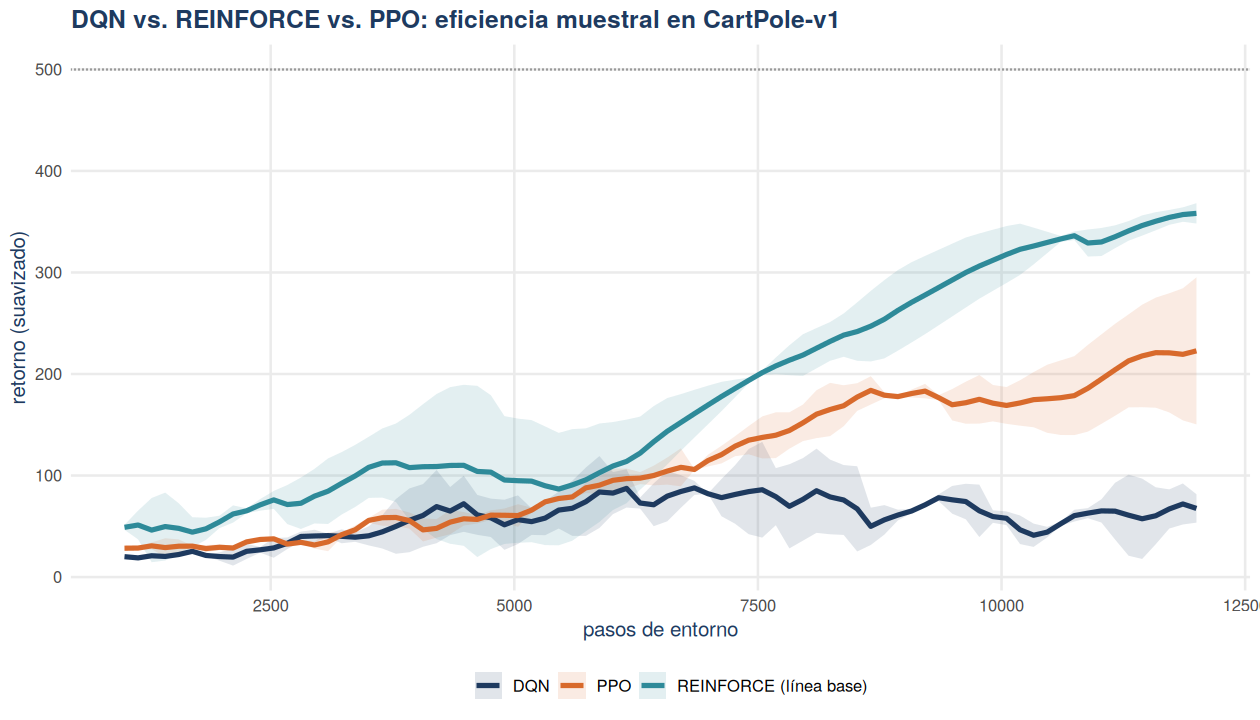

In [15]:
# Interpolación sobre rejilla común de pasos de entorno (approx)
options(repr.plot.width = 10.5, repr.plot.height = 6)
rejilla <- seq(1000, min(DQN_PASOS, PPO_PASOS), length.out = 80)
interp_banda <- function(curvas, etiqueta) {
  series <- lapply(curvas, function(c) {
    rs <- media_movil(c$ret, 10L); ps <- c$pasos[(length(c$pasos) - length(rs) + 1L):length(c$pasos)]
    approx(ps, rs, xout = rejilla, rule = 2)$y })
  M <- do.call(cbind, series)
  data.frame(pasos = rejilla, media = rowMeans(M),
             sd = if (ncol(M) > 1) apply(M, 1, sd) else 0, alg = etiqueta)
}
# REINFORCE con línea base: reconstruir pasos acumulados desde longitudes
curvas_rei <- lapply(seq_len(N_REPLICAS), function(k) {
  list(ret = curvas_con[[k]], pasos = cumsum(pmax(1, curvas_con[[k]]))) })
df_cmp <- rbind(interp_banda(curvas_dqn, "DQN"),
                interp_banda(curvas_rei, "REINFORCE (línea base)"),
                interp_banda(curvas_ppo, "PPO"))
ggplot(df_cmp, aes(pasos, media, color = alg, fill = alg)) +
  geom_ribbon(aes(ymin = media - sd, ymax = media + sd), alpha = 0.13, color = NA) +
  geom_line(linewidth = 1.1) +
  scale_color_manual(values = c("DQN" = COLOR_NAVY,
        "REINFORCE (línea base)" = COLOR_TEAL, "PPO" = COLOR_ORANGE)) +
  scale_fill_manual(values = c("DQN" = COLOR_NAVY,
        "REINFORCE (línea base)" = COLOR_TEAL, "PPO" = COLOR_ORANGE)) +
  geom_hline(yintercept = 500, linetype = "dotted", color = COLOR_GRAY) +
  labs(title = "DQN vs. REINFORCE vs. PPO: eficiencia muestral en CartPole-v1",
       x = "pasos de entorno", y = "retorno (suavizado)", color = NULL, fill = NULL)

In [16]:
# Tabla de estadísticas finales (media ± sd insesgada sobre réplicas)
final_de <- function(curvas, esLista = TRUE) {
  vals <- sapply(curvas, function(c) {
    r <- if (esLista) c$ret else c; mean(tail(r, 10)) })
  c(media = mean(vals), sd = if (length(vals) > 1) sd(vals) else NA)
}
tabla <- rbind(
  DQN                    = final_de(curvas_dqn),
  `REINFORCE (sin base)` = final_de(curvas_sin, esLista = FALSE),
  `REINFORCE (con base)` = final_de(curvas_con, esLista = FALSE),
  PPO                    = final_de(curvas_ppo))
cat("Retorno final por algoritmo (media ± sd insesgada sobre réplicas):\n\n")
print(round(as.data.frame(tabla), 1))
cat(sprintf("\n(Promedios sobre %d réplicas; retorno máximo = 500.)\n", N_REPLICAS))

Retorno final por algoritmo (media ± sd insesgada sobre réplicas):



                     media    sd
DQN                   67.6  14.0
REINFORCE (sin base)  96.6  41.6
REINFORCE (con base) 425.6 105.3
PPO                  219.2  68.0



(Promedios sobre 2 réplicas; retorno máximo = 500.)


> **Sobre la reproducibilidad y los generadores aleatorios.** El cómputo numérico de este cuaderno ocurre en el **núcleo de Python** (PCG64 de `numpy`, generador de PyTorch), invocado vía `reticulate`; las semillas de R (`set.seed`, Mersenne-Twister) gobiernan únicamente la orquestación. Por ello, y a diferencia de los cuadernos tabulares, **no se persigue la paridad numérica exacta** ni entre lenguajes ni entre ejecuciones: la inicialización estocástica de las redes y el no determinismo del cómputo en punto flotante lo impiden. La reproducibilidad es **estadística**: razonamos sobre medias y dispersiones de varias réplicas. Esta es, justamente, la lección metodológica que el cuaderno comparte con su contraparte Python.

## Bloque 6 — Síntesis y ejercicios propuestos

### Lo que el cuaderno R mostró

* El **puente `reticulate`** permite a un usuario de R aprovechar el ecosistema de RL profundo de Python sin abandonar su lenguaje: el cómputo ocurre en PyTorch, mientras R orquesta, organiza en `data.frame` y visualiza con `ggplot2`.
* Las **conversiones defensivas** (`convert = FALSE`, `as.numeric`, `as.logical`) y el alojamiento del núcleo numérico en Python evitan los desbordes de pila propios de la conversión recursiva de objetos pesados.
* Las tres lecciones de fondo coinciden con el cuaderno Python: DQN vuelve viable Q-Learning sobre estado continuo; la línea base reduce la varianza del gradiente sin sesgo; y PPO ofrece la mayor estabilidad.

### Ejercicios propuestos

Mantienen exacta correspondencia con los del cuaderno Python.

1. **Teórico 1.** Demuestre que una línea base $b(s)$ independiente de la acción no introduce sesgo en el gradiente de política, partiendo de $\mathbb{E}_{a\sim\pi}[\nabla_\theta\log\pi_\theta(a\mid s)]=0$.
2. **Teórico 2.** Derive la equivalencia entre minimizar la pérdida de DQN con red objetivo fija y un paso de Q-Learning, identificando el papel de $\mathbf{w}^{-}$.
3. **Computacional 1.** Amplíe el estudio del periodo $C$ y de la capacidad del *replay buffer* sobre la estabilidad de la curva, promediando sobre varias réplicas. Reproduzca las figuras con `ggplot2`.
4. **Computacional 2.** Extienda la cuantificación de la reducción de varianza del gradiente: estudie su dependencia de $\gamma$ y del tamaño de la red del crítico.
5. **Integrador.** Contraste DQN, REINFORCE y PPO bajo idéntico presupuesto de pasos; discuta eficiencia muestral, estabilidad y rendimiento final con intervalos de confianza.

> **Entrega evaluativa (Unidad 4 — componente de RL profundo).** Plazo: **8 de junio, 23:59 hs**. Resolver el ejercicio teórico 1 y el computacional 1, más una de las dos opciones avanzadas. Entregar el PDF junto al **notebook ejecutado** (con sus salidas visibles) por el aula virtual.

---

*Fin del cuaderno R de la Clase 5. Las dudas se canalizan por el foro específico de la clase.*

**Dr. Darío Ezequiel Díaz** — Universidad Austral, Facultad de Ingeniería.